# Zero-Shot Pet Breed Classification with CLIP

This notebook applies OpenAI's CLIP (`clip-vit-base-patch32`), a multimodal vision-language transformer, to classify 37 pet breeds in the Oxford-IIIT Pet dataset without any task-specific fine-tuning. Classification is done by comparing image embeddings against text embeddings of candidate class descriptions and selecting the closest match.

A key experiment demonstrates **prompt engineering**: modifying only the text inputs (not the model weights) to push accuracy from ~80% to above 87%.

GPU acceleration is recommended. Inference over ~3,700 images is fast on GPU but slow on CPU. CUDA and Apple MPS are both supported.

## 1. Model, Preprocessor & Dataset

**CLIP** (`clip-vit-base-patch32`) consists of two encoders trained jointly via contrastive learning on 400 million image-text pairs:
- A **Vision Transformer (ViT)** encodes images into embedding vectors
- A **Text Transformer** encodes text strings into embedding vectors

Classification is done by computing cosine similarity between the image embedding and the text embedding for each candidate label; no task-specific training required.

The **Oxford-IIIT Pet** test split contains ~3,700 images across 37 breeds (12 cat, 25 dog). Labels are breed indices into `class_names`.

In [1]:
# Load CLIP model, preprocessor, and Oxford Pets test dataset

import os
import torch
from torchvision.datasets import CIFAR10, OxfordIIITPet
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

pets = OxfordIIITPet(root=os.path.expanduser("~/.cache"), download=True, split="test")
class_names = pets.classes
class_to_species = {
    # Cats
    'Abyssinian': 'cat', 'Bengal': 'cat', 'Birman': 'cat', 'Bombay': 'cat',
    'British Shorthair': 'cat', 'Egyptian Mau': 'cat', 'Maine Coon': 'cat',
    'Persian': 'cat', 'Ragdoll': 'cat', 'Russian Blue': 'cat', 'Siamese': 'cat',
    'Sphynx': 'cat',
    # Dogs
    'American Bulldog': 'dog', 'American Pit Bull Terrier': 'dog', 'Basset Hound': 'dog',
    'Beagle': 'dog', 'Boxer': 'dog', 'Chihuahua': 'dog', 'English Cocker Spaniel': 'dog', 
    'English Setter': 'dog', 'German Shorthaired': 'dog', 'Great Pyrenees': 'dog',
    'Havanese': 'dog', 'Japanese Chin': 'dog', 'Keeshond': 'dog', 'Leonberger': 'dog',
    'Miniature Pinscher': 'dog', 'Newfoundland': 'dog', 'Pomeranian': 'dog', 'Pug': 'dog',
    'Saint Bernard': 'dog', 'Samoyed': 'dog', 'Scottish Terrier': 'dog', 'Shiba Inu': 'dog',
    'Staffordshire Bull Terrier': 'dog', 'Wheaten Terrier': 'dog', 'Yorkshire Terrier': 'dog',
    }

/home/users/gcc14/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-11-14 11:58:20.864058: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


A sample image and its ground-truth breed label are visualized below.

0
Abyssinian


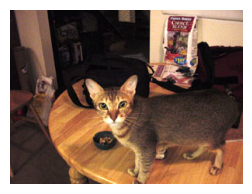

In [2]:
# Visualize the first image and its ground-truth breed label

import matplotlib.pyplot as plt

# Get the image and ground truth label for first image as an example
image, class_id = pets[0]
print(class_id)
print(class_names[class_id])
      
# Visualize the image
plt.figure(figsize=(3, 3))
plt.axis("off")
plt.imshow(image)
plt.show()

## 2. Zero-Shot Inference

The `predict_class` function passes an image and a list of text strings to CLIP and returns the index of the text label with the highest logit, the model's predicted breed. No training or fine-tuning is involved; CLIP's pretrained image-text alignment does the work.

In [3]:
# predict_class helper: returns the index of the best-matching text label

def predict_class(model, inputs):
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    return torch.argmax(logits_per_image, dim=1).item()


example_inputs = preprocess(
    text=[c for c in class_names],
    images=image,
    return_tensors="pt",
    padding=True,
    )


print(predict_class(model, example_inputs))

0


## 3. Baseline Accuracy — Raw Class Names

The baseline evaluation uses bare breed names as text inputs (e.g. `"Abyssinian"`, `"Pug"`). All 37 class names are passed as candidate labels for every image.

In [4]:
# Inspect a sample label index
print(pets[1][1])

0


In [7]:
# Evaluate baseline accuracy over the full dataset using raw class names
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
correct = 0

for i in range(len(pets)):
    example = pets[i]
    image = example[0]

    example_inputs = preprocess(
        text=[c for c in class_names],
        images=image,
        return_tensors="pt",
        padding=True,
        ).to(device)

    prediction = predict_class(model, example_inputs)

    if prediction == example[1]:
        correct += 1
        
    if((i+1) % 100 == 0):
        print(f"{i+1} predictions completed")


print(f"Accuracy: {correct / len(pets)}")

100 predictions completed
200 predictions completed
300 predictions completed
400 predictions completed
500 predictions completed
600 predictions completed
700 predictions completed
800 predictions completed
900 predictions completed
1000 predictions completed
1100 predictions completed
1200 predictions completed
1300 predictions completed
1400 predictions completed
1500 predictions completed
1600 predictions completed
1700 predictions completed
1800 predictions completed
1900 predictions completed
2000 predictions completed
2100 predictions completed
2200 predictions completed
2300 predictions completed
2400 predictions completed
2500 predictions completed
2600 predictions completed
2700 predictions completed
2800 predictions completed
2900 predictions completed
3000 predictions completed
3100 predictions completed
3200 predictions completed
3300 predictions completed
3400 predictions completed
3500 predictions completed
3600 predictions completed
Accuracy: 0.8004905968928864


## 4. Prompt Engineering

CLIP was pretrained on natural descriptive text, not bare taxonomic labels. Richer text inputs better match the style of CLIP's training data and provide additional disambiguating context.

The engineered prompt template:
```
"Picture of a pet with breed: {breed}, which is a type of {cat/dog}"
```

This adds two pieces of information: a framing phrase that matches natural image captioning style, and the species label (cat vs. dog) drawn from `class_to_species`, helping CLIP resolve ambiguous breed names.

In [11]:
# Evaluate accuracy with enriched text prompts

correct = 0

for i in range(len(pets)):
    example = pets[i]
    image = example[0]

    example_inputs = preprocess(
        text=[f"Picture of a pet with breed: {c}, which is a type of {class_to_species.get(c)}" for c in class_names],
        images=image,
        return_tensors="pt",
        padding=True,
        ).to(device)

    prediction = predict_class(model, example_inputs)

    if prediction == example[1]:
        correct += 1
        
    if((i+1) % 100 == 0):
        print(f"{i+1} predictions completed")


print(f"Accuracy: {correct / len(pets)}")

100 predictions completed
200 predictions completed
300 predictions completed
400 predictions completed
500 predictions completed
600 predictions completed
700 predictions completed
800 predictions completed
900 predictions completed
1000 predictions completed
1100 predictions completed
1200 predictions completed
1300 predictions completed
1400 predictions completed
1500 predictions completed
1600 predictions completed
1700 predictions completed
1800 predictions completed
1900 predictions completed
2000 predictions completed
2100 predictions completed
2200 predictions completed
2300 predictions completed
2400 predictions completed
2500 predictions completed
2600 predictions completed
2700 predictions completed
2800 predictions completed
2900 predictions completed
3000 predictions completed
3100 predictions completed
3200 predictions completed
3300 predictions completed
3400 predictions completed
3500 predictions completed
3600 predictions completed
Accuracy: 0.8822567457072772
